# 0 Outset

## 0.1 Imports & Configurations

In [88]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import top_k_accuracy_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## 0.2 Data Loading

In [35]:
# Loading the processed dataset
DATA_PATH = '../data/processed/crop_features_v1.csv'
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"  Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Columns : {df.columns.tolist()}")
print()
df.head(10)

Dataset loaded successfully.
  Shape   : 2200 rows × 11 columns
  Columns : ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'moisture_index', 'P_to_K', 'ph_dev', 'label']



,N,P,K,temperature,humidity,ph,rainfall,moisture_index,P_to_K,ph_dev,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,9.719701,0.976744,0.002985,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,9.809501,1.414634,0.538096,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,9.986483,1.250000,1.340207,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,9.876557,0.875000,0.480401,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,9.973014,1.000000,1.128473,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,9.949010,0.880952,0.573454,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,10.017848,1.447368,0.799194,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,9.906445,1.325000,0.781373,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,9.865338,1.421053,0.185346,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,9.818404,1.526316,0.163746,rice


# 1.0 Logistic Regression

## 1.1 Define Features & Label

In [36]:
# Defining the features (X) and the label (y)
features = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 
    'rainfall', 'moisture_index', 'P_to_K', 'ph_dev'
]

X = df[features]
y = df['label']

## 1.2 Split the Dataset

In [37]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 1.3 Feature Scaling

In [38]:
# Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1.4 Initializing and Training the Logistic Regression Model 
This is the initial Logistic Regression model without hyperparameters. This model is trained for benchmark purposes against the one with tuned hyperparameters. We will be doing the same (training a model with and without tuned hyperparameters) for all the other machine learning algorithms we use throughout this notebook, to compare the results and arrive at the best performing model.

In [6]:
# Initialize and train the Logistic Regression model
# max_iter is increased because multi-class problems might require more iterations to converge
log_reg_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

## 1.5 Making Predictions on the Test Dataset

In [7]:
# Make predictions on the test set
y_pred_untuned = log_reg_model.predict(X_test_scaled)

## 1.6 Untuned Logistic Regression Model Evaluation

In [10]:
accuracy = accuracy_score(y_test, y_pred_untuned)
print(f"Accuracy: {accuracy * 100:.4f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_untuned))

Accuracy: 98.1818%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      0.95      0.95        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      0.95      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90     

## 1.7 Untuned Logistic Regression Confusion Matrix and Heatmap

Raw Logistic Regression Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  0 19  0  0  0  0  0  0

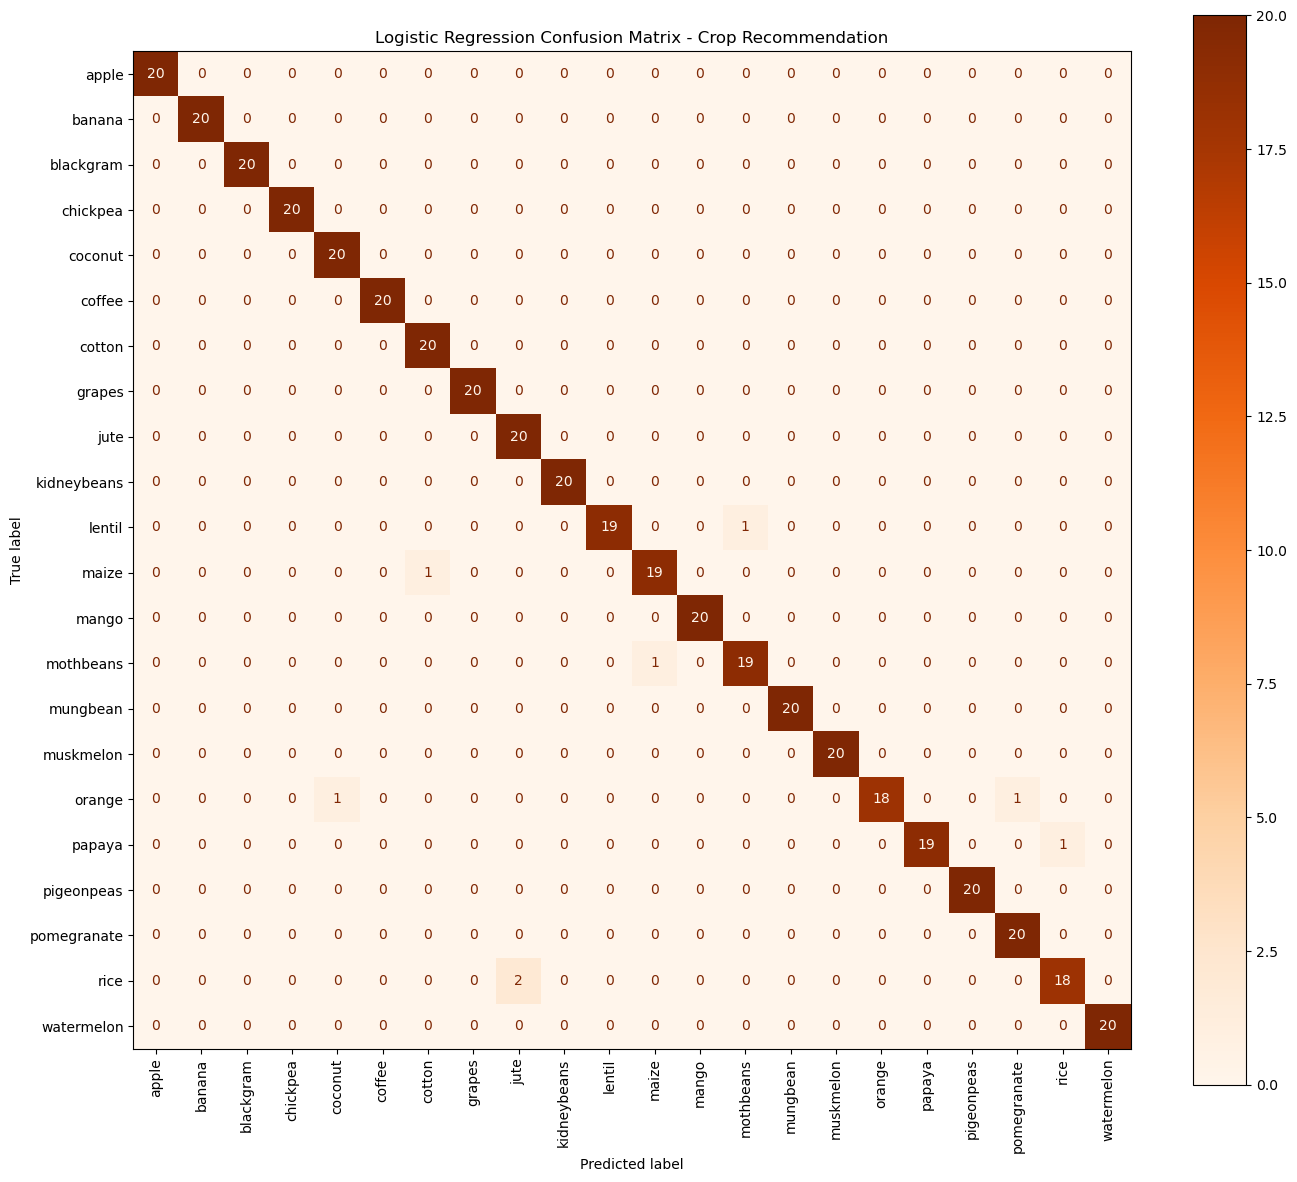

In [11]:
# Remember to use the scaled test data here as well!
y_pred_log = log_reg_model.predict(X_test_scaled)

# Calculate the raw confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

print("Raw Logistic Regression Confusion Matrix:")
print(cm_log)

# Create the visual heatmap
# Pulling the class labels from the trained Logistic Regression model
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_reg_model.classes_)

# Create a large figure to fit the 22 crop names comfortably
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix. Let's use 'Oranges' to visually distinguish this 
# from the Decision Tree (Blues) and SVM (Greens) plots.
disp_log.plot(cmap='Oranges', ax=ax, xticks_rotation='vertical')

plt.title('Logistic Regression Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()

## 1.8 Logistic Regression with Hyperparameter Tuning 

### 1.8.1 Tuned LR: Define the Hyperparameter Grid

The hyperparameters we are tuning are:

-`C (Regularization Strength)`: This controls how closely the model tries to fit the training data. A lower value (like 0.01) forces a simpler model to prevent overfitting, while a higher value (like 100.0) allows the model to become highly complex.

-`solver`: This is the mathematical algorithm used to find the optimal weights for our features.

-`lbfgs`: The default, generally fast and good for multi-class problems.

-`newton-cg`: A computationally heavier solver that can sometimes find a more precise minimum for the cost function.

-`saga`: Extremely efficient for very large datasets and supports different types of penalties (though we are defaulting to standard L2 here).

-`max_iter`: Some solvers take longer to find the solution. Giving them 2000 or 10000 iterations ensures they don't give up and throw a convergence warning before finishing the math.

In [12]:
# We are testing different combinations of regularization strength and solvers
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'newton-cg', 'saga'],
    'max_iter': [2000, 5000, 10000] # Added higher limits, because saga kept converging before 2000
}

### 1.8.2 Tuned LR: Initialize the Base Model and GridSearchCV

In [13]:
base_log_reg = LogisticRegression(random_state=42)

# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all CPU cores to speed up the search
grid_search = GridSearchCV(
    estimator=base_log_reg, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1 # Prints out the progress
)

### 1.8.3 Tuned LR: Run Grid Search

In [14]:
# This will train and evaluate a model for EVERY combination of parameters above
print("Starting Grid Search... This may take a moment.\n")
grid_search.fit(X_train_scaled, y_train)

Starting Grid Search... This may take a moment.

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1.0, 10.0, 100.0],
                         'max_iter': [2000, 5000, 10000],
                         'solver': ['lbfgs', 'newton-cg', 'saga']},
             scoring='accuracy', verbose=1)

### 1.8.4 Tuned LR: Extract and Evaluate the Best Model

In [16]:
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.4f}%\n")

# The grid search automatically saves the best performing model
best_model = grid_search.best_estimator_

# Test the best model on our unseen test set
y_pred_tuned = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"Test Set Accuracy with Best Model: {test_accuracy * 100:.5f}%\n")
print("Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

Best Hyperparameters Found: {'C': 100.0, 'max_iter': 2000, 'solver': 'newton-cg'}
Best Cross-Validation Accuracy: 98.2386%

Test Set Accuracy with Best Model: 99.09091%

Classification Report (Tuned Model):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00   

### 1.8.5 Tuned LR: Confusion Matrix and Heatmap for the Tuned Logistic Regression Model

Raw Tuned Logistic Regression Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0

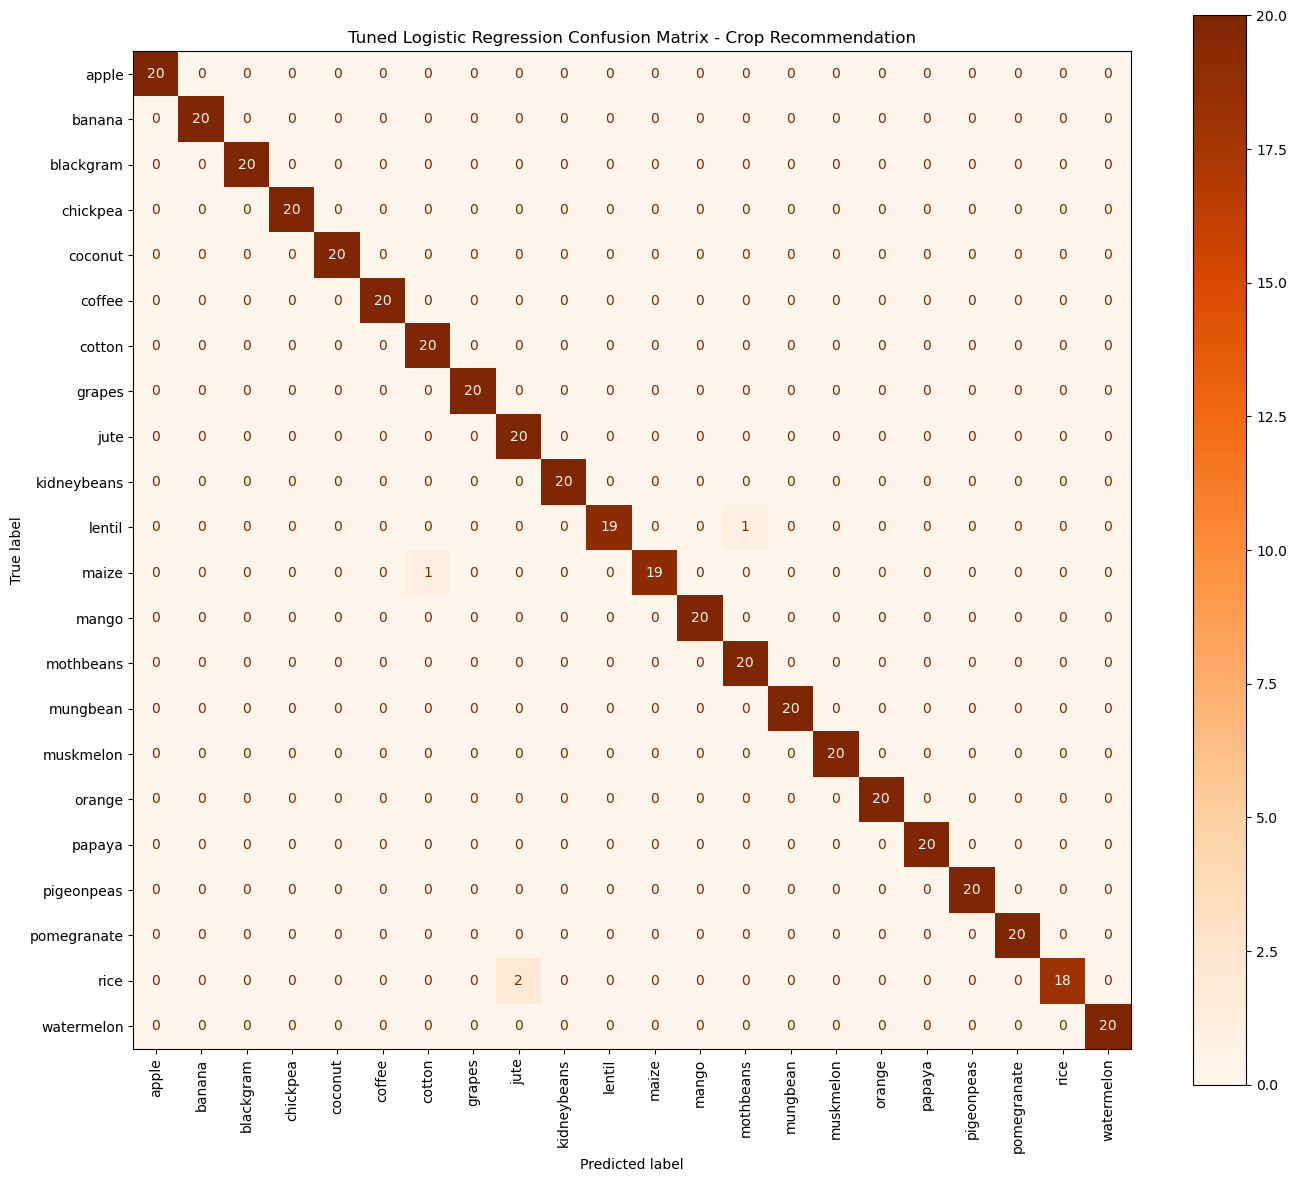

In [25]:
# Calculate the raw confusion matrix using the tuned predictions
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Raw Tuned Logistic Regression Confusion Matrix:")
print(cm_tuned)

# Create the visual heatmap
# We pull the class labels directly from the tuned model
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=best_model.classes_)

# Create a large figure to fit the 22 crop names comfortably
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using 'Oranges' to keep it consistent with the previous Logistic Regression plot
disp_tuned.plot(cmap='Oranges', ax=ax, xticks_rotation='vertical')

plt.title('Tuned Logistic Regression Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()

## 1.9 Comparison of Logistic Regression with and without Tuning
Here, though the results are marginal, we can clearly see that the model with hyperparameter tuning performs better.

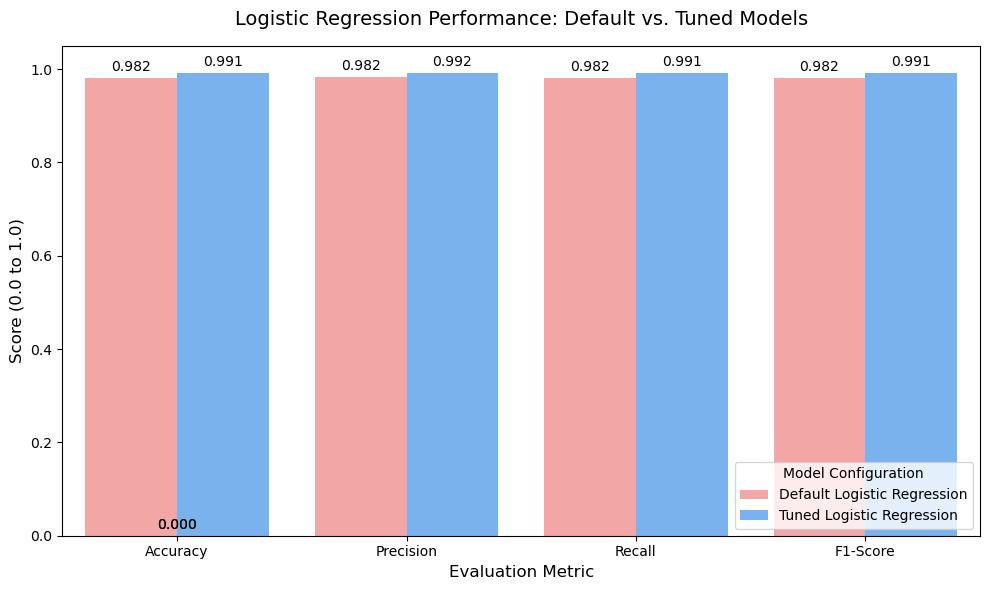

Best parameters found during tuning: {'C': 100.0, 'max_iter': 2000, 'solver': 'newton-cg'}


In [19]:
# We use average='macro' because this is a multi-class dataset. 
# It calculates the metric for each crop independently and finds the unweighted mean.
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0)
    ]

metrics_default = get_metrics(y_test, y_pred_untuned)
metrics_tuned = get_metrics(y_test, y_pred_tuned)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Create a DataFrame to easily plot with seaborn
plot_df = pd.DataFrame({
    'Metric': metrics_names * 2,
    'Score': metrics_default + metrics_tuned,
    'Model': ['Default Logistic Regression'] * 4 + ['Tuned Logistic Regression'] * 4
})

plt.figure(figsize=(10, 6))

# A grouped bar chart to put the default vs tuned bars right next to each other
sns.barplot(
    data=plot_df, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=['#FF9999', '#66B2FF'] # Soft red for default, nice blue for tuned
)

# Formatting the chart
plt.title('Logistic Regression Performance: Default vs. Tuned Models', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0.0, 1.05) # Give a little headroom above 1.0 for the legend
plt.legend(title='Model Configuration', loc='lower right')

# Add the exact numbers on top of the bars for clarity
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 8), 
                       textcoords='offset points',
                       fontsize=10)

plt.tight_layout()
plt.show()

print(f"Best parameters found during tuning: {grid_search.best_params_}")

# 2.0 SVM

## 2.1 Feature Scaling

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2.2 Initialize and Train SVM

In [40]:
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

## 2.3 Prediction and Evaluation

In [41]:
y_pred_default_svm = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_default_svm)
print(f"Accuracy: {accuracy * 100:.4f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_default_svm))

Accuracy: 98.6364%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.87      1.00      0.93        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      0.90     

## 2.4 Untuned SVM Confusion Matrix and Heatmap 

Raw SVM Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0 

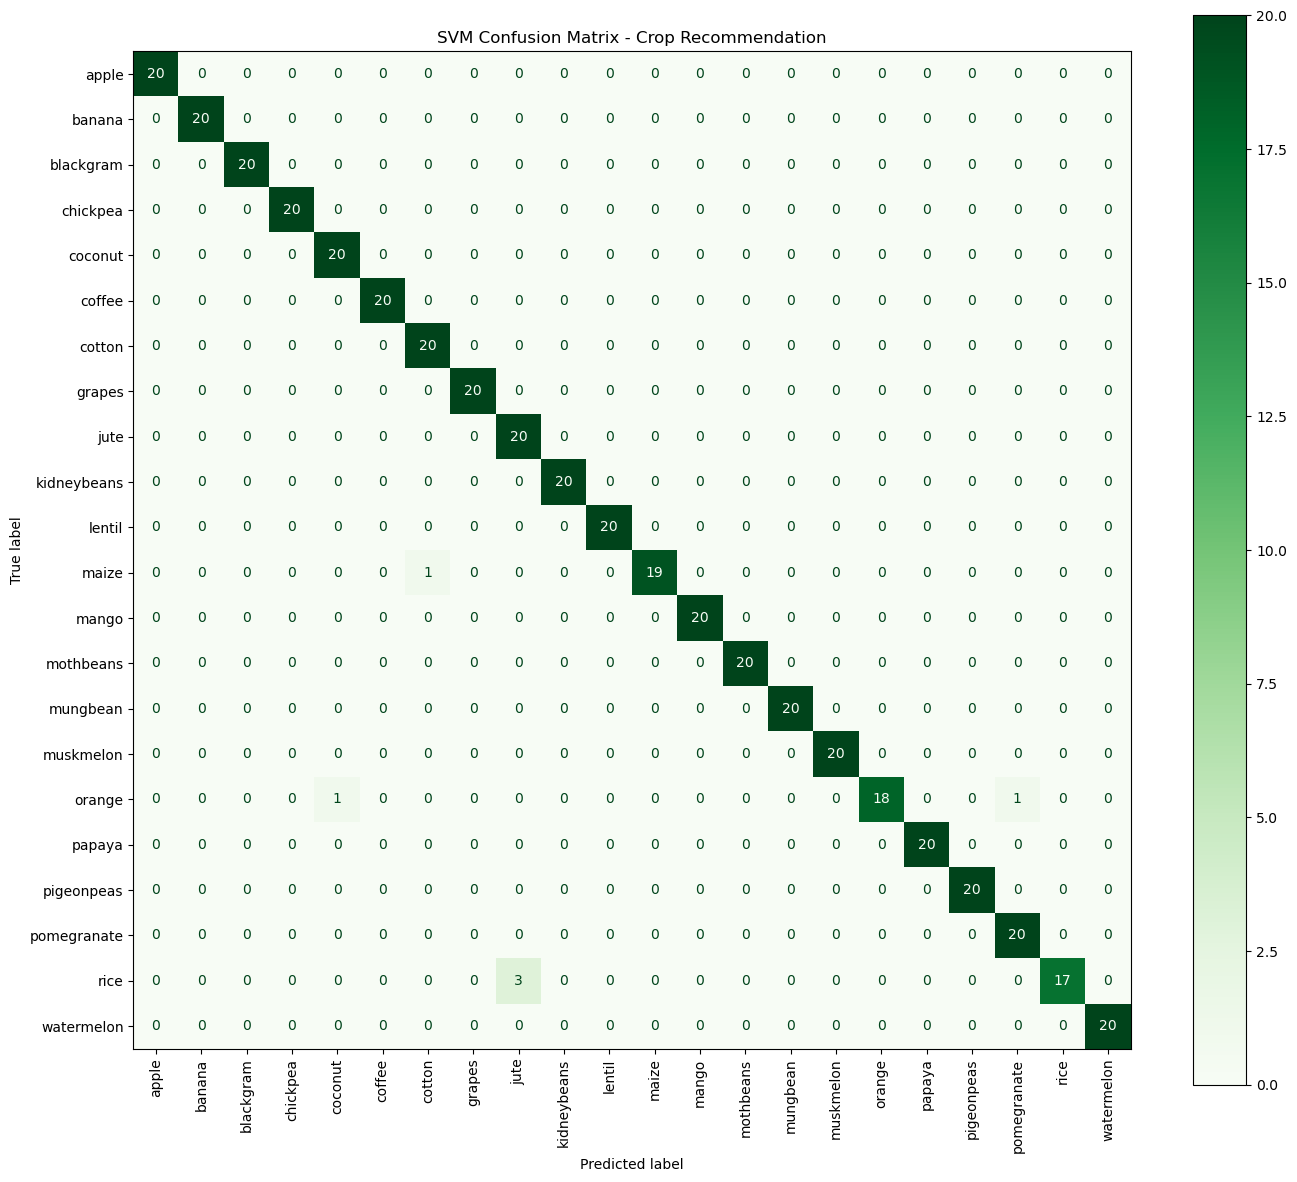

In [43]:
# Generate predictions using the SVM model
y_pred_svm = svm_model.predict(X_test_scaled)

# Calculate the raw confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Raw SVM Confusion Matrix:")
print(cm_svm)

# Create the visual heatmap
# We pull the class labels directly from the trained SVM model
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)

# Create a large figure to comfortably fit all 22 crop names
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix
disp_svm.plot(cmap='Greens', ax=ax, xticks_rotation='vertical')

plt.title('SVM Confusion Matrix - Crop Recommendation')
plt.tight_layout() # Keeps the crop labels from getting cut off at the edges
plt.show()

## 2.6 SVM with Hyperparameter Tuning

### 2.6.1 Tuned SVM: Define the Grid

The hyperparameters that we are tuning are:

-`C (Regularization)`: Just like with Logistic Regression, this controls the trade-off between a smooth decision boundary and classifying training points correctly. High C means a strict, complex boundary. Low C means a smoother, more forgiving boundary.

-`kernel`: This determines the shape of the geometric boundary.

-`linear`: Tries to draw flat planes between the crop classes. It is very fast but might fail if the data is highly complex.

-`rbf` (Radial Basis Function): The default. It can wrap around complex clusters of data by projecting them into higher dimensions.

-`gamma`: This is only used by the 'rbf' kernel. It defines how far the influence of a single training point reaches.

A high value (like 0.1) means a point only influences things very close to it, leading to tighter, more jagged boundaries.

A low value (like 0.01) means the point has a broad influence, leading to smoother boundaries. 'scale' and 'auto' are smart defaults that calculate gamma based on your number of features and their variance.

In [44]:
# We are testing different combinations of regularization (C), kernel types, and kernel widths (gamma)
param_grid_svm = {
    'C': [0.1, 1, 10, 100], 
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

### 2.6.2 Tuned SVM: Initialize Base Model

In [45]:
base_svm = SVC(random_state=42)

# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all CPU cores
# verbose=2 prints detailed progress because SVM tuning can be slow
grid_search_svm = GridSearchCV(
    estimator=base_svm, 
    param_grid=param_grid_svm, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=2 
)

### 2.6.3 Tuned SVM: Run Grid Search

In [46]:
print("Starting SVM Grid Search... Grab a coffee, this might take a minute!\n")
grid_search_svm.fit(X_train_scaled, y_train)

Starting SVM Grid Search... Grab a coffee, this might take a minute!

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.1, 0.01],
                         'kernel': ['rbf', 'linear']},
             scoring='accuracy', verbose=2)

### 2.6.3 Tuned SVM: Extract and Evaluate Best Model

In [48]:
print(f"\nBest Hyperparameters Found: {grid_search_svm.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_svm.best_score_ * 100:.4f}%\n")

# The grid search automatically saves the best performing model
best_svm_model = grid_search_svm.best_estimator_

# Test the best model on the unseen test set
y_pred_best_svm = best_svm_model.predict(X_test_scaled)
test_accuracy_svm = accuracy_score(y_test, y_pred_best_svm)

print(f"Test Set Accuracy with Best SVM: {test_accuracy_svm * 100:.4f}%\n")
print("Classification Report (Tuned SVM):")
print(classification_report(y_test, y_pred_best_svm))


Best Hyperparameters Found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 98.8636%

Test Set Accuracy with Best SVM: 98.8636%

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.90      0.95        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95      

### 2.6.4 Tuned SVM: Confusion Matrix and Heatmap of Tuned SVM Model

Raw Tuned SVM Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 18  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [

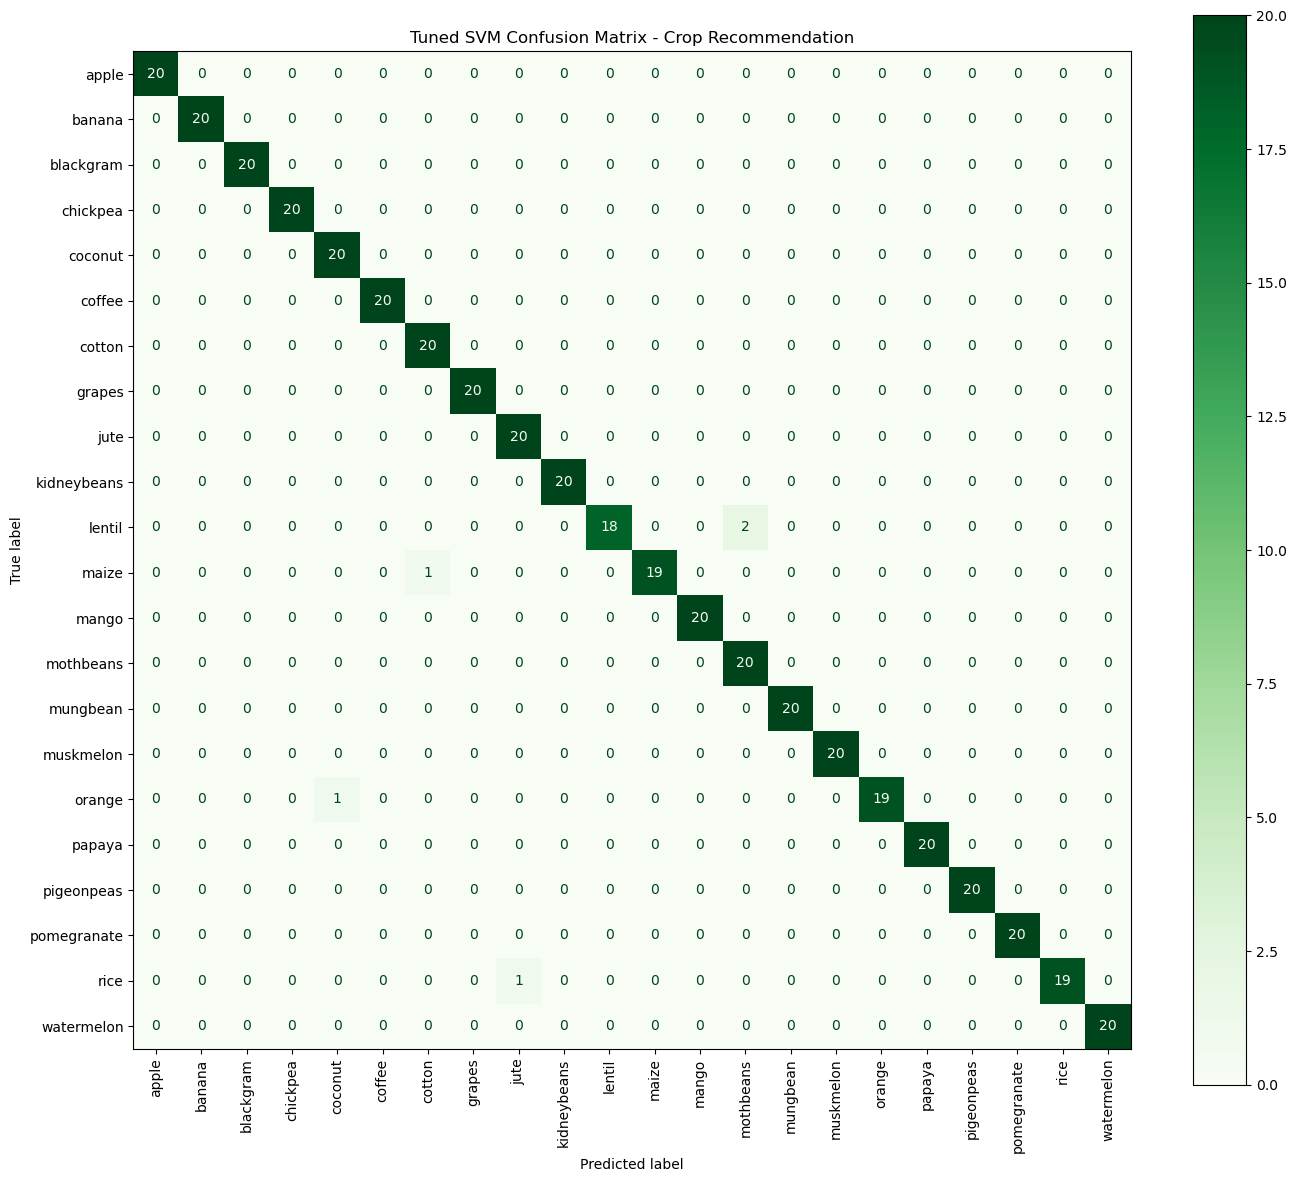

In [51]:
# Calculate the raw confusion matrix using the tuned predictions
cm_tuned_svm = confusion_matrix(y_test, y_pred_best_svm)

print("Raw Tuned SVM Confusion Matrix:")
print(cm_tuned_svm)

# Create the visual heatmap
# We pull the class labels directly from the tuned model
disp_tuned_svm = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_svm, display_labels=best_svm_model.classes_)

# Create a large figure to comfortably fit all 22 crop names
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using 'Greens' to keep it consistent with the previous SVM plot
disp_tuned_svm.plot(cmap='Greens', ax=ax, xticks_rotation='vertical')

plt.title('Tuned SVM Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()

## 2.7 Comparing Results of Tuned vs Untuned SVM
Once again, while the difference is marginal (0.001 to 0.003 difference), the tuned model outperforms the untuned one.

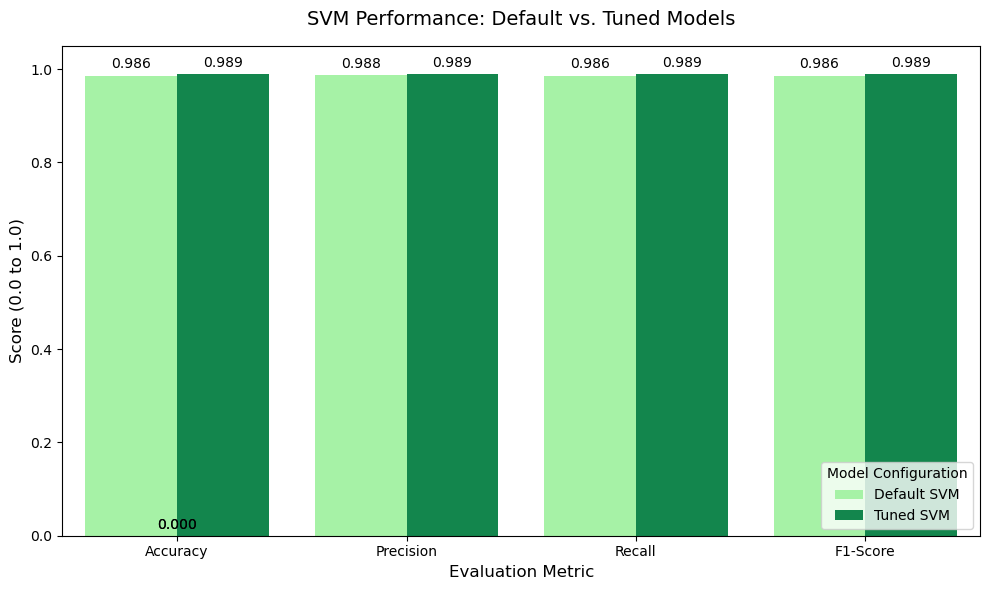

In [49]:
# Calculate metrics for both SVM versions
metrics_default_svm = get_metrics(y_test, y_pred_default_svm)
metrics_tuned_svm = get_metrics(y_test, y_pred_best_svm)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plot_df_svm = pd.DataFrame({
    'Metric': metrics_names * 2,
    'Score': metrics_default_svm + metrics_tuned_svm,
    'Model': ['Default SVM'] * 4 + ['Tuned SVM'] * 4
})

plt.figure(figsize=(10, 6))

# Using a green color palette to match your previous SVM heatmap
sns.barplot(
    data=plot_df_svm, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=['#99FF99', '#00994D'] # Light green for default, bold green for tuned
)

# Formatting the chart
plt.title('SVM Performance: Default vs. Tuned Models', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0.0, 1.05) 
plt.legend(title='Model Configuration', loc='lower right')

# Add the exact decimal numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 8), 
                       textcoords='offset points',
                       fontsize=10)

plt.tight_layout()
plt.show()

# 3.0 Decision Tree

## 3.1 Data Preparation & Splitting
We intentionally skip the StandardScaler step here

In [60]:
features = [
    'N', 'P', 'K', 'temperature', 'humidity', 'ph', 
    'rainfall', 'moisture_index', 'P_to_K', 'ph_dev'
]

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 3.2 Initializing Decision Tree

In [61]:
# We set max_depth to prevent the tree from growing too complex and overfitting
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

## 3.3 Prediction and Evaluation

In [62]:
y_pred_tree_untuned = tree_model.predict(X_test)

decision_tree_accuracy = accuracy_score(y_test, y_pred_tree_untuned)
print(f"Accuracy: {decision_tree_accuracy * 100:.4f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_tree_untuned))

Accuracy: 96.8182%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.65      1.00      0.78        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.85      0.55      0.67        20
       mango       0.95      1.00      0.98        20
   mothbeans       1.00      0.95      0.97        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00     

## 3.4 Untuned Decision Tree Confusion Matrix and Heatmap

Raw Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  8  0  0 11  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  0 19  0  0  0  0  0  0  0  0]
 [ 0  0  0  

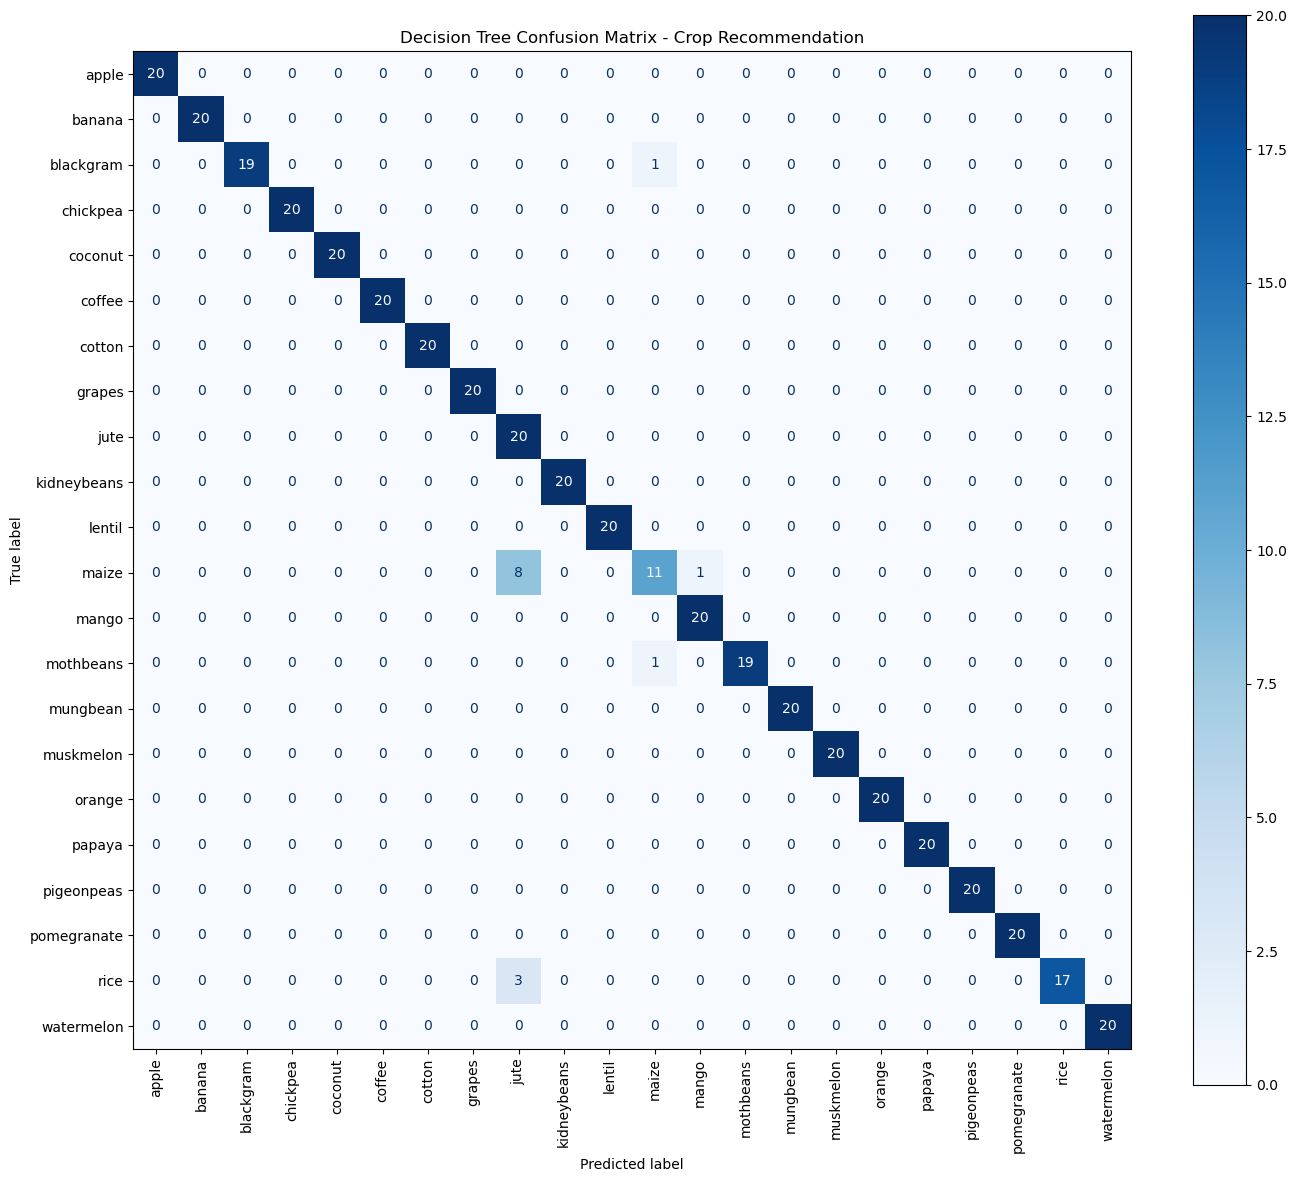

In [63]:
# 1. Calculate the raw confusion matrix
cm = confusion_matrix(y_test, y_pred_tree_untuned)

# 2. Print the simple text version
print("Raw Confusion Matrix:")
print(cm)

# 3. Create a visual heatmap (Highly Recommended for multi-class)
# We use the classes_ attribute from your trained tree_model for the labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_model.classes_)

# Create a large figure so the 22 crop names don't overlap
fig, ax = plt.subplots(figsize=(14, 12))

# Plot the matrix using a blue color map, rotating x-labels to make them readable
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title('Decision Tree Confusion Matrix - Crop Recommendation')
plt.tight_layout() # Ensures labels fit within the image
plt.show()

## 3.5 Decision Tree with Hyperparameter Tuning

### 3.5.1 Tuned Decision Tree: Define Grid

The hyperparameters that were chosen to tune are: 
-`criterion`: The function used to measure the quality of a split.

-`gini`: Measures node impurity (the default we used earlier).

-`entropy`: Measures information gain. It involves a slightly more complex calculation (logarithms) but can sometimes yield a more balanced tree.

-`max_depth`: The absolute maximum number of questions the tree can ask before being forced to make a prediction. None allows it to grow infinitely until all leaves are pure, which we balance against the other parameters below.

-`min_samples_split`: The minimum number of data points required to split an internal node. If we set this to 10, a bucket with only 9 crops in it will not be split any further, forcing the tree to stop growing in that direction.

-`min_samples_leaf`: The minimum number of data points required to form a final "leaf" (the final prediction bucket). Setting this to 2 or 4 prevents the tree from creating a highly specific leaf that only caters to a single outlier data point.

In [64]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

### 3.5.2 Tuned Decision Tree: Initialize Base Model and GridSearchCV

In [65]:
base_dt = DecisionTreeClassifier(random_state=42)

# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all CPU cores
grid_search_dt = GridSearchCV(
    estimator=base_dt, 
    param_grid=param_grid_dt, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=1 
)

### 3.5.3 Tuned Decision Tree: Run Grid Search

In [66]:
print("Starting Decision Tree Grid Search...\n")
grid_search_dt.fit(X_train, y_train)

Starting Decision Tree Grid Search...

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy', verbose=1)

### 3.5.4 Tuned Decision Tree: Extract and Evaluate Best Model

In [67]:
print(f"Best Hyperparameters Found: {grid_search_dt.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_dt.best_score_ * 100:.4f}%\n")

# The grid search automatically saves the best performing model
best_dt_model = grid_search_dt.best_estimator_

# Test the best model on the unseen test set
y_pred_best_dt = best_dt_model.predict(X_test)
test_accuracy_dt = accuracy_score(y_test, y_pred_best_dt)

print(f"Test Set Accuracy with Best Decision Tree: {test_accuracy_dt * 100:.4f}%\n")
print("Classification Report (Tuned Decision Tree):")
print(classification_report(y_test, y_pred_best_dt))

Best Hyperparameters Found: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross-Validation Accuracy: 98.3523%

Test Set Accuracy with Best Decision Tree: 98.6364%

Classification Report (Tuned Decision Tree):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.90      0.95      0.93        20
       mango       0.95      1.00      0.

### 3.5.5 Tuned Decision Tree: Confusion Matrix and Heatmap for Tuned Decision Tree

Raw Tuned Decision Tree Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  0 19  0  0  0  0  0  0

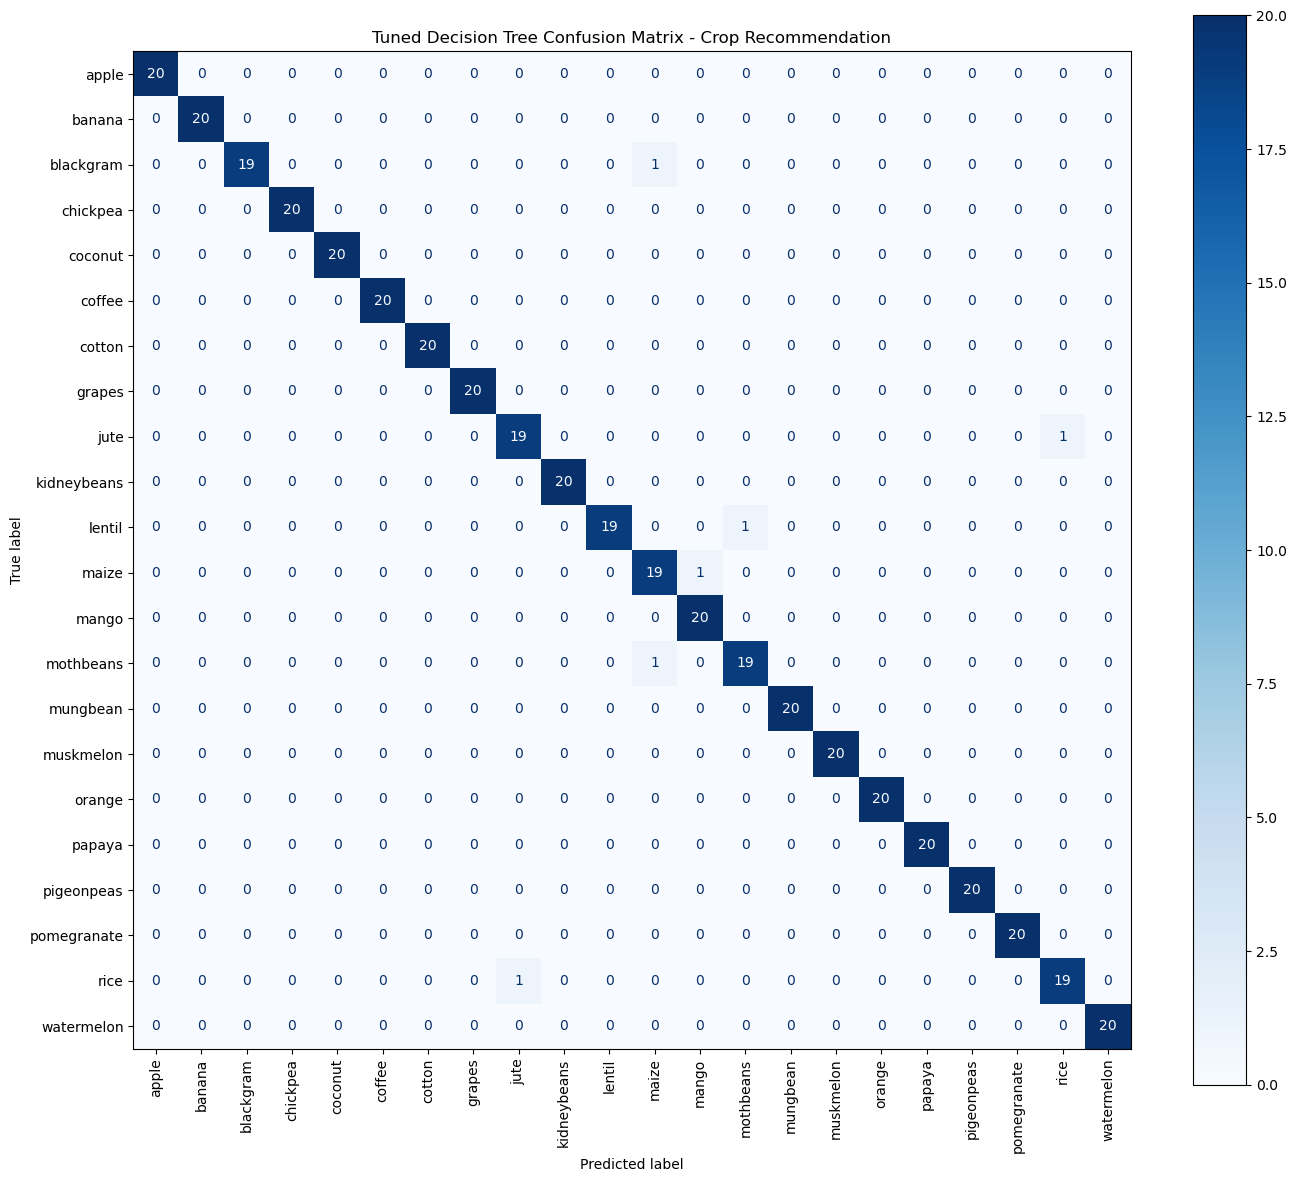

In [70]:
# Plot the confusion matrix
cm_tuned_dt = confusion_matrix(y_test, y_pred_best_dt)

print("Raw Tuned Decision Tree Confusion Matrix:")
print(cm_tuned_dt)

disp_tuned_dt = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_dt, display_labels=best_dt_model.classes_)

fig, ax = plt.subplots(figsize=(14, 12))

# Keeping the 'Blues' colormap for consistency
disp_tuned_dt.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')

plt.title('Tuned Decision Tree Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()

## 3.6 Tuned vs Untuned Decision Tree Model Performance Comparison
The tuned Decision Tree model decisively performs better than its untuned counterpart, moreso than the previous models.

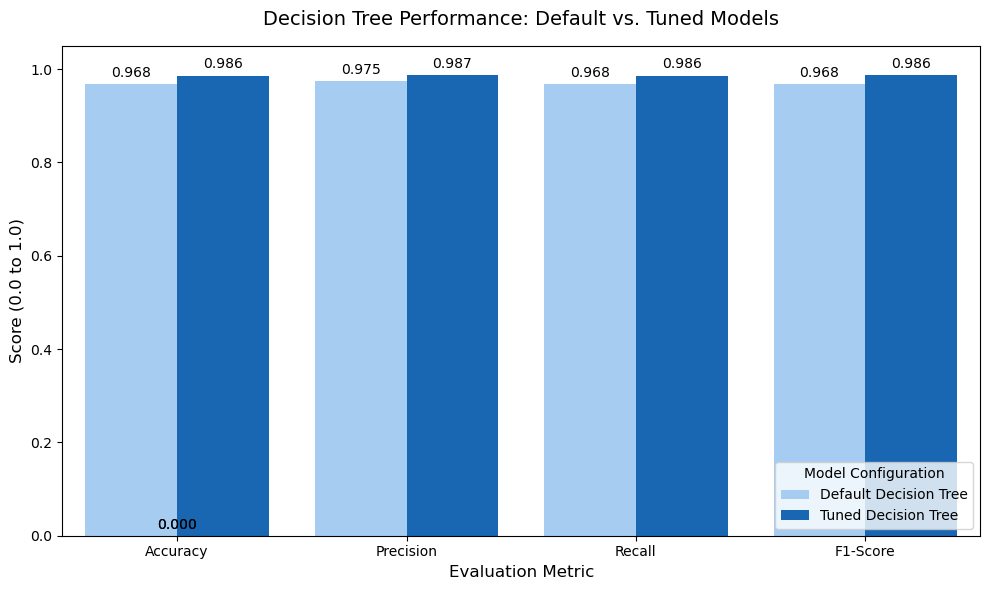

In [69]:
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0)
    ]

# Calculate metrics for both Decision Tree versions
metrics_default_dt = get_metrics(y_test, y_pred_tree_untuned)
metrics_tuned_dt = get_metrics(y_test, y_pred_best_dt)

# --- STEP 4: Prepare Data for the Bar Chart ---
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plot_df_dt = pd.DataFrame({
    'Metric': metrics_names * 2,
    'Score': metrics_default_dt + metrics_tuned_dt,
    'Model': ['Default Decision Tree'] * 4 + ['Tuned Decision Tree'] * 4
})

# --- STEP 5: Plot the Bar Chart Comparison ---
plt.figure(figsize=(10, 6))

# Using a blue color palette to match your original Decision Tree heatmap
sns.barplot(
    data=plot_df_dt, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=['#99CCFF', '#0066CC'] # Light blue for default, dark blue for tuned
)

plt.title('Decision Tree Performance: Default vs. Tuned Models', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0.0, 1.05) 
plt.legend(title='Model Configuration', loc='lower right')

# Add the exact decimal numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 8), 
                       textcoords='offset points',
                       fontsize=10)

plt.tight_layout()
plt.show()

# 4.0 Random Forest

## 4.1 Data Loading and Splitting

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4.2 Initialize and Train Random Forest

In [72]:
# n_estimators is the number of trees in the forest. 
# n_jobs=-1 tells the model to use all available CPU cores for faster training.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_jobs=-1, random_state=42)

## 4.3 Predict and Evaluate

In [74]:
y_pred_rf_untuned = rf_model.predict(X_test)

rf_untuned_accuracy = accuracy_score(y_test, y_pred_rf_untuned)
print(f"Accuracy: {rf_untuned_accuracy * 100:.4f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf_untuned))

Accuracy: 99.5455%

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00     

## 4.4 Untuned Rnadom Forest Confusion Matrix and Heatmap

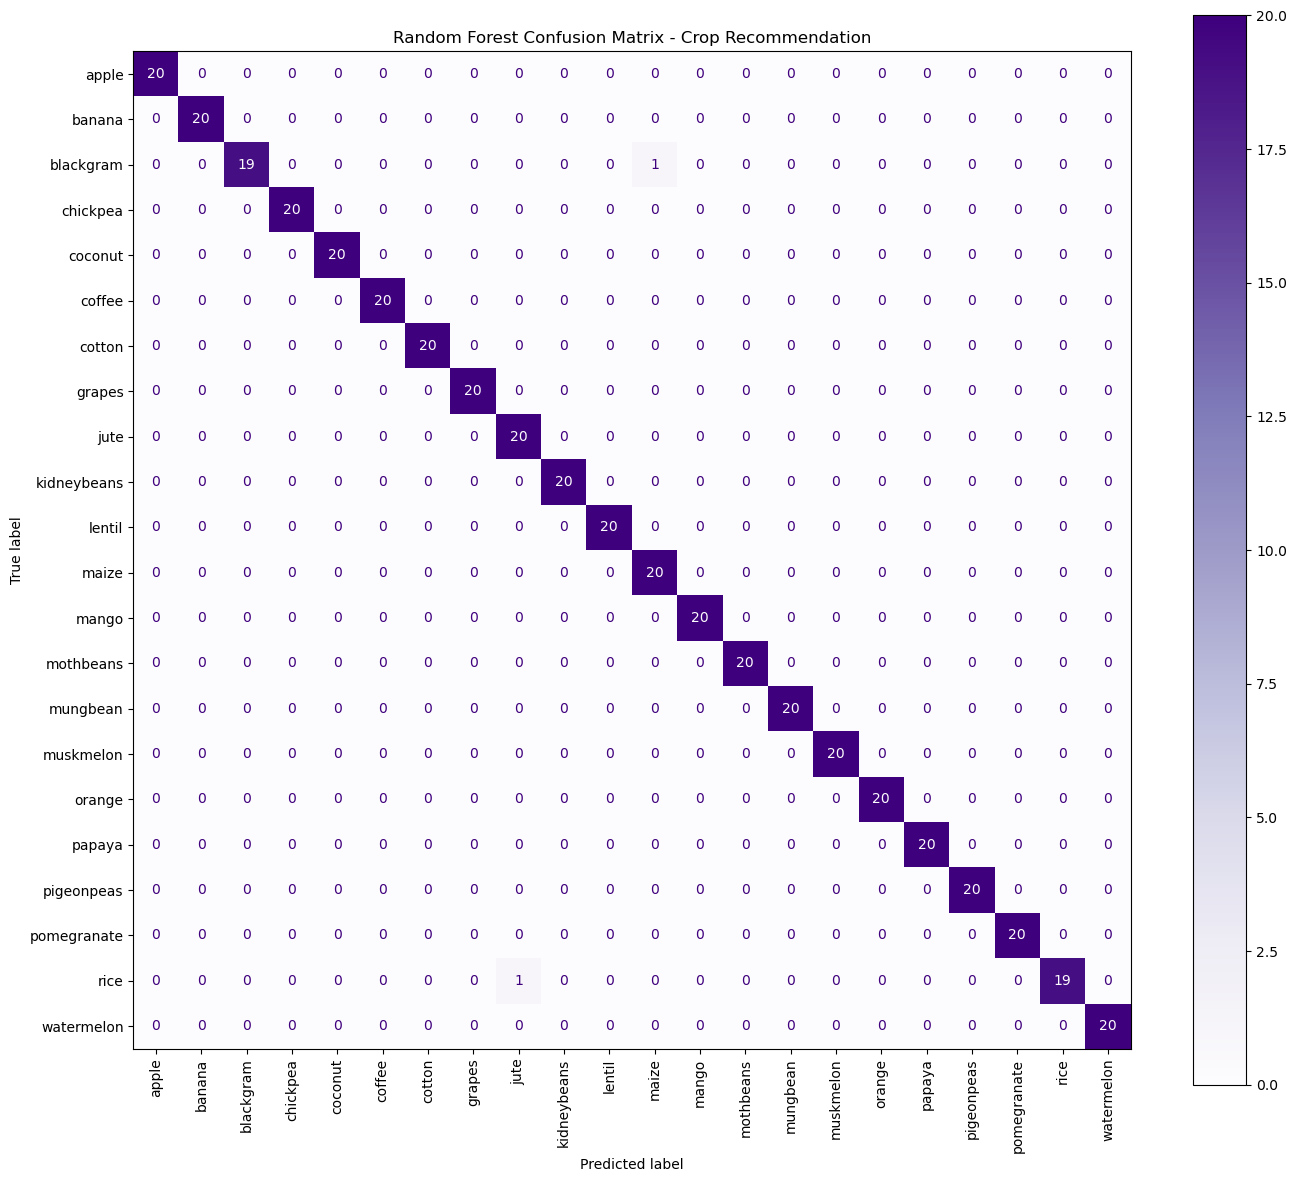

In [75]:
cm_rf = confusion_matrix(y_test, y_pred_rf_untuned)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)

fig, ax = plt.subplots(figsize=(14, 12))
# Using 'Purples' to distinguish from Logistic (Oranges), SVM (Greens), and Decision Tree (Blues)
disp_rf.plot(cmap='Purples', ax=ax, xticks_rotation='vertical')

plt.title('Random Forest Confusion Matrix - Crop Recommendation')
plt.tight_layout()
plt.show()

## 4.5 Untuned Random Forest Feature Importance
This part can be deleted, I will leave it up to the report writer

Feature Importances:
       Feature  Importance
      humidity    0.179999
      rainfall    0.160764
             K    0.143609
moisture_index    0.136725
             P    0.123146
             N    0.091706
        P_to_K    0.077376
   temperature    0.046041
            ph    0.027918
        ph_dev    0.012716




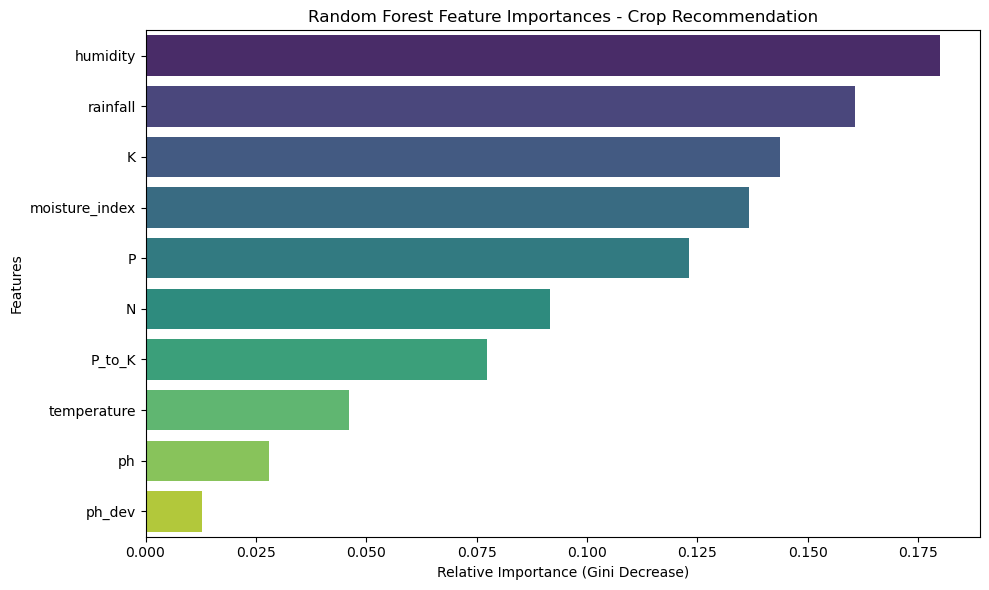

In [76]:
importances = rf_model.feature_importances_

# Create a DataFrame for easy sorting and plotting 
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort the features from most to least important 
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the exact numerical values for reference
print("Feature Importances:")
print(feature_importance_df.to_string(index=False))
print("\n")

# Plot the Feature Importances
plt.figure(figsize=(10, 6))

# We use a horizontal bar chart (x='Importance', y='Feature') because it makes 
# the feature names much easier to read without overlapping.
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)

plt.title('Random Forest Feature Importances - Crop Recommendation')
plt.xlabel('Relative Importance (Gini Decrease)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## 4.6 Random Forest with Hyperparameter Tuning

### 4.6.1 Tuned Random Forest: Define the Hyperparameter Grid

The hyperparameters we are tuning are:
-`n_estimators`: This is the total number of Decision Trees in the forest.

-50 trains quickly but might have slightly less voting power.

-200 gives the forest exceptional robust voting power to cancel out individual tree errors, but it takes four times as long to train.

-`max_depth`: Just like with the single Decision Tree, this limits how many sequential questions a tree can ask. By testing 10, 15, 20, and None (unlimited), we can find the sweet spot between capturing complex crop relationships and preventing the trees from over-memorizing the data.

-`min_samples_split`: This dictates the minimum number of data points a bucket needs to have before it is allowed to split again. A higher number (like 10) forces the individual trees to be simpler and broader.

In [77]:
# We are testing the number of trees, their maximum depth, and how they split
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

### 4.6.2 Tuned Random Forest: Initialize Base Model and GridSearchCV

In [78]:
base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all CPU cores to speed up the grid search
# verbose=2 gives you real-time updates in the terminal
grid_search_rf = GridSearchCV(
    estimator=base_rf, 
    param_grid=param_grid_rf, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1,
    verbose=2 
)

### 4.6.3 Tuned Random Forest: Run Grid Search

In [79]:
print("Starting Random Forest Grid Search... This will train thousands of trees!\n")
grid_search_rf.fit(X_train, y_train)

Starting Random Forest Grid Search... This will train thousands of trees!

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 15, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=2)

### 4.6.4 Tuned Random Forest: Extract and Evaluate Best Model

In [80]:
print(f"\nBest Hyperparameters Found: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_rf.best_score_ * 100:.4f}%\n")

# The grid search automatically saves the best performing model
best_rf_model = grid_search_rf.best_estimator_

# Test the best model on the unseen test set
y_pred_best_rf = best_rf_model.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_pred_best_rf)

print(f"Test Set Accuracy with Best Random Forest: {test_accuracy_rf * 100:.4f}%\n")
print("Classification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_best_rf))


Best Hyperparameters Found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation Accuracy: 99.3750%

Test Set Accuracy with Best Random Forest: 99.3182%

Classification Report (Tuned Random Forest):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbe

### 4.6.5 Tuned Random Forest: Confusion Matrix and Heatmap of Tuned Random Forest Model

Raw Tuned Random Forest Confusion Matrix:
[[20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 19  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 19  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0

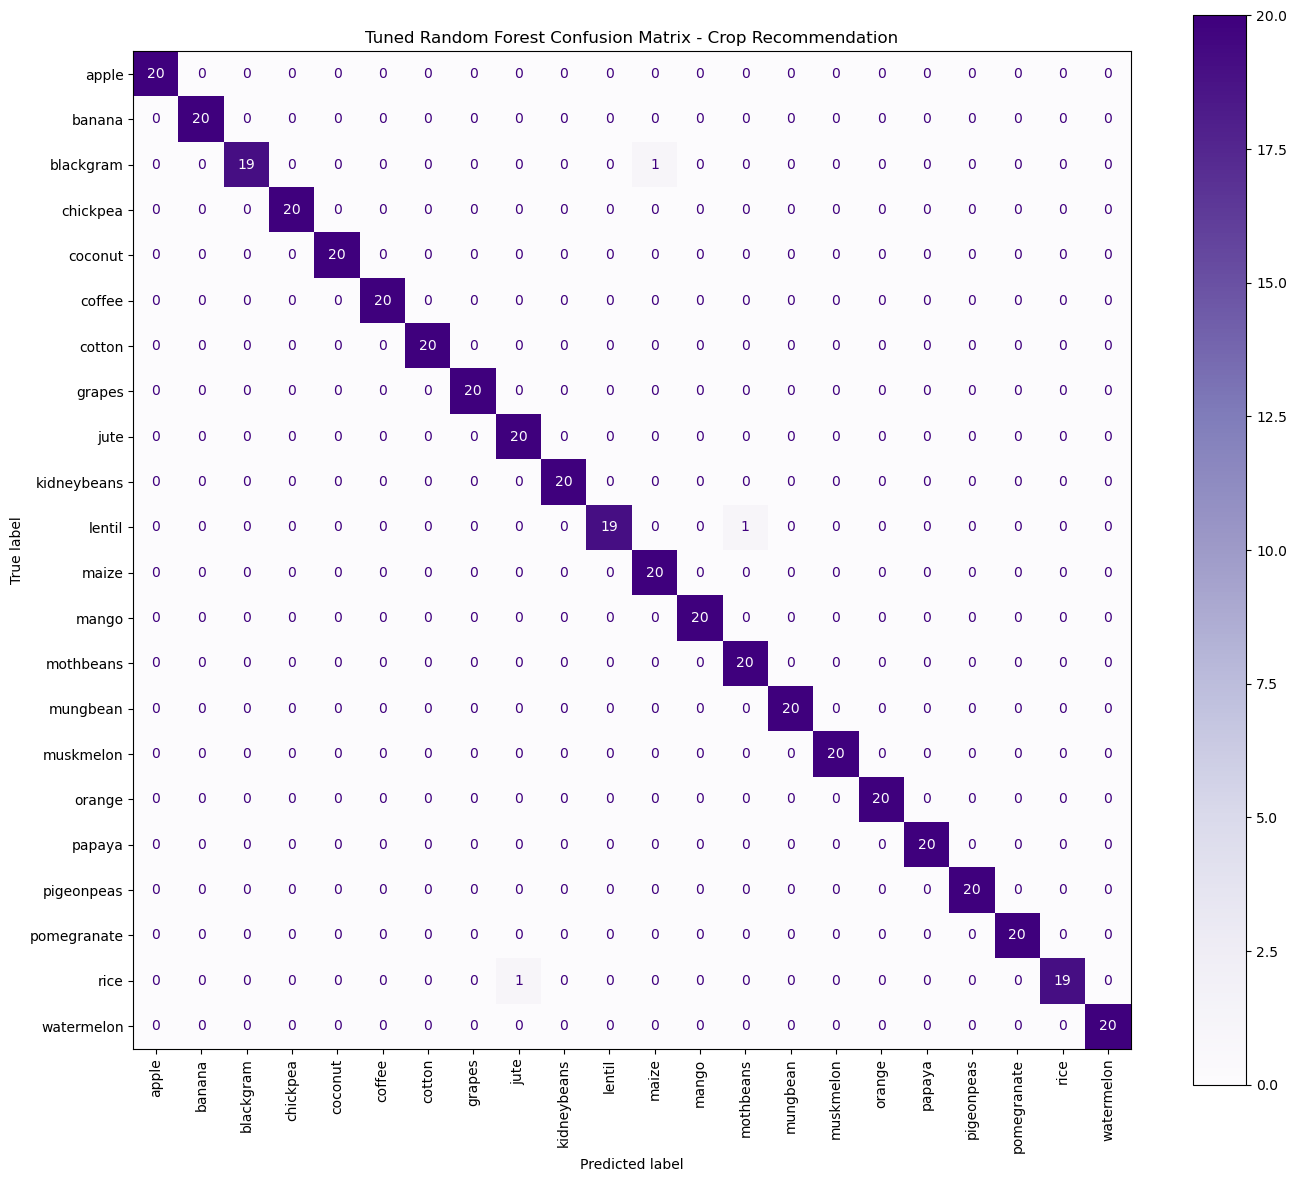

In [82]:
cm_tuned_rf = confusion_matrix(y_test, y_pred_best_rf)

print("Raw Tuned Random Forest Confusion Matrix:")
print(cm_tuned_rf)

disp_tuned_rf = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_rf, display_labels=best_rf_model.classes_)

fig, ax = plt.subplots(figsize=(14, 12))

# Keeping the 'Purples' colormap for consistency
disp_tuned_rf.plot(cmap='Purples', ax=ax, xticks_rotation='vertical')

plt.title('Tuned Random Forest Confusion Matrix - Crop Recommendation')
plt.tight_layout() 
plt.show()

## 4.7 Comparing Tuned vs. Untuned Random Forest Model

Interestingly, the untuned Random Forest performs better than the tuned model. The discussion for why this might be is given in section 5.1.

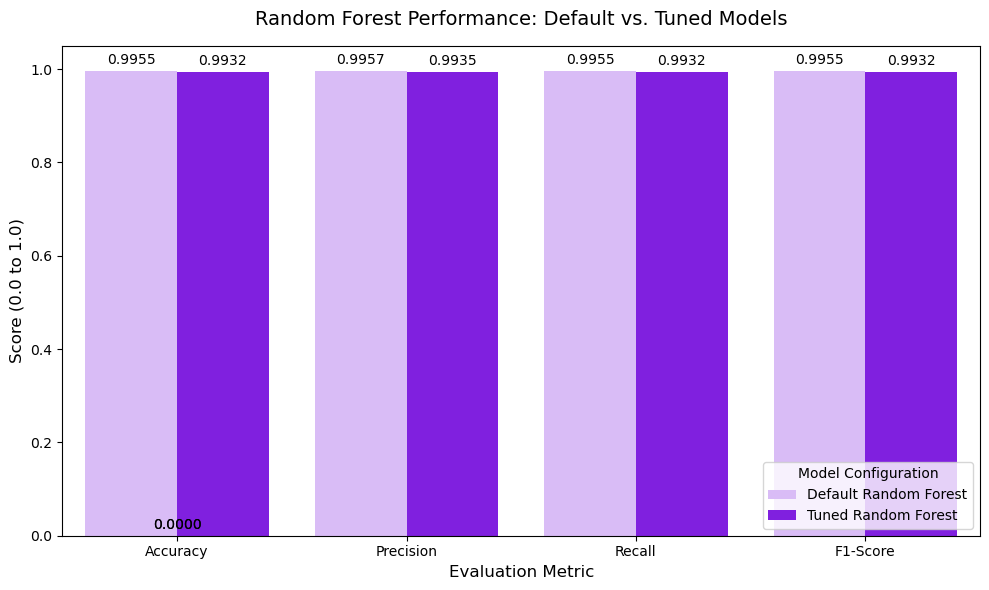

In [83]:
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0)
    ]

# Calculate metrics for both Random Forest versions
metrics_default_rf = get_metrics(y_test, y_pred_rf_untuned)
metrics_tuned_rf = get_metrics(y_test, y_pred_best_rf)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plot_df_rf = pd.DataFrame({
    'Metric': metrics_names * 2,
    'Score': metrics_default_rf + metrics_tuned_rf,
    'Model': ['Default Random Forest'] * 4 + ['Tuned Random Forest'] * 4
})

# Plot the bar chart
plt.figure(figsize=(10, 6))

# Using a purple color palette to match your original Random Forest heatmap
sns.barplot(
    data=plot_df_rf, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=['#D9B3FF', '#8000FF'] # Light purple for default, bold purple for tuned
)

plt.title('Random Forest Performance: Default vs. Tuned Models', fontsize=14, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylim(0.0, 1.05) 
plt.legend(title='Model Configuration', loc='lower right')

# Add the exact decimal numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 8), 
                       textcoords='offset points',
                       fontsize=10)

plt.tight_layout()
plt.show()

# 5.0 Comparing Logistic Regression, SVM, Decision Tree and Random Forest Models

For this comparison, we will take the best performing model (tuned or untuned) from each of the categories.

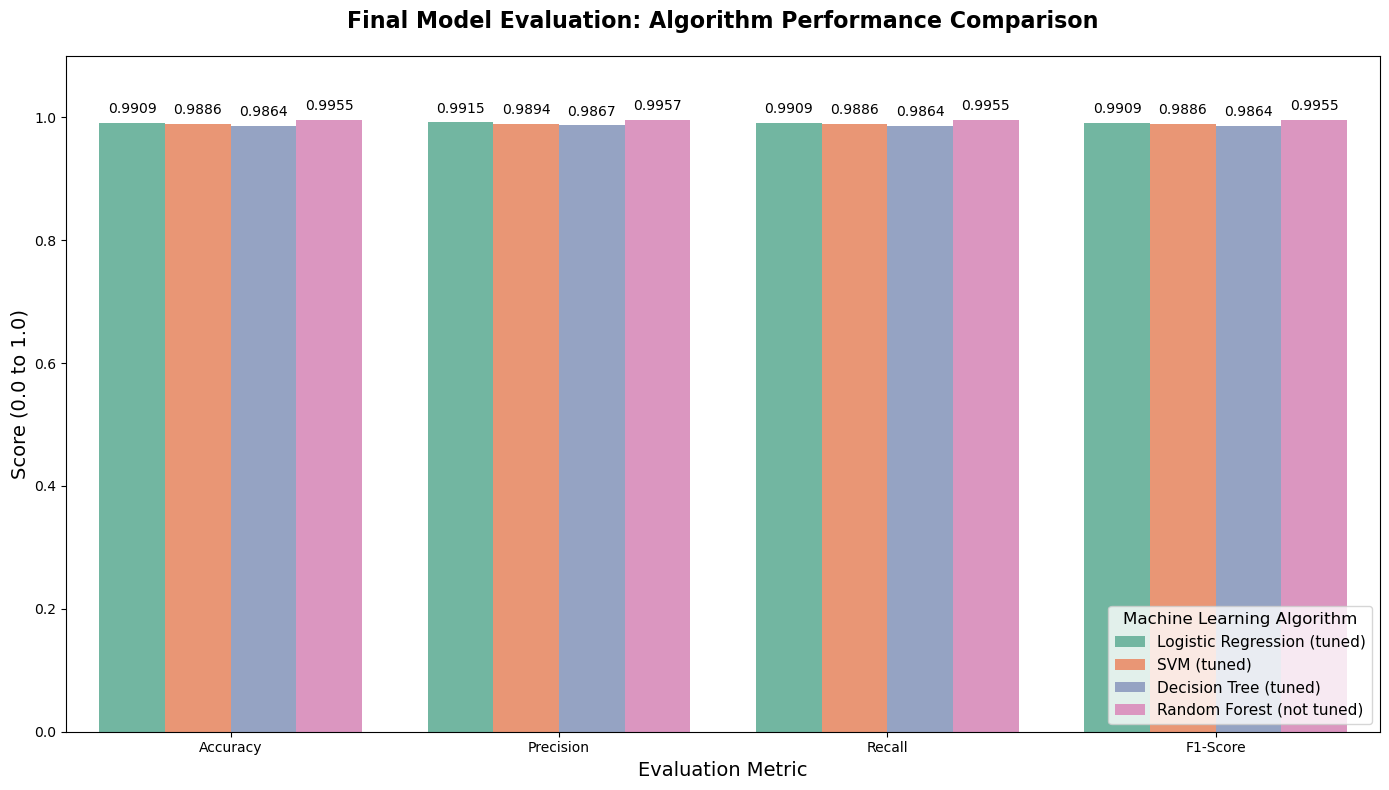

In [86]:
def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1_score(y_true, y_pred, average='macro', zero_division=0)
    ]
# These are the prediction variables from the best performing models :
# y_pred_tuned (Tuned Logistic Regression)
# y_pred_best_svm (Tuned SVM) 
# y_pred_best_dt (Tuned Decision Tree)
# y_pred_rf_untuned (Default/Untuned Random Forest)

metrics_log = get_metrics(y_test, y_pred_tuned)
metrics_svm = get_metrics(y_test, y_pred_best_svm)
metrics_dt = get_metrics(y_test, y_pred_best_dt)
metrics_rf = get_metrics(y_test, y_pred_rf_untuned)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = ['Logistic Regression (tuned)', 'SVM (tuned)', 'Decision Tree (tuned)', 'Random Forest (not tuned)']

# Flatten the data into for seaborn
plot_data = []
all_metrics = [metrics_log, metrics_svm, metrics_dt, metrics_rf]

for model_idx, model_metrics in enumerate(all_metrics):
    for metric_idx, score in enumerate(model_metrics):
        plot_data.append({
            'Model': model_names[model_idx],
            'Metric': metrics_names[metric_idx],
            'Score': score
        })

plot_df_final = pd.DataFrame(plot_data)

# Plot the chart
# Making the figure slightly wider to comfortably fit 16 total bars
plt.figure(figsize=(14, 8))

# Using a distinct, professional color palette ('Set2' is great for presentations)
ax = sns.barplot(
    data=plot_df_final, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette='Set2'
)

# Formatting the chart for usage in the report
plt.title('Final Model Evaluation: Algorithm Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score (0.0 to 1.0)', fontsize=14)
plt.xlabel('Evaluation Metric', fontsize=14)
plt.ylim(0.0, 1.1) # Extra headroom for labels and legend
plt.legend(title='Machine Learning Algorithm', title_fontsize='12', loc='lower right', fontsize='11')

# Add the exact decimal numbers on top of the bars, slightly rotated for readability
for p in ax.patches:
    # Skip rendering if the bar height is 0 (fixes the 0.000 matplotlib glitch)
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=10,
                    rotation=0)

plt.tight_layout()
plt.show()

## 5.1 Discussion of Model Comparison Results
The untuned Random Forest model is our best performing model. Here are some reasons why we believe we obtained the results we did:

1. The Nature of Agricultural Data
To understand why Random Forest won, we have to look at the dataset itself. Crop data is highly non-linear and relies on strict environmental thresholds. For example, a crop might thrive if the temperature is between 20°C and 25°C, but fail completely if it drops to 19°C or jumps to 26°C.

- Logistic Regression (0.9909): This algorithm tries to draw straight lines (or planes) through the data. It struggles to capture those "goldilocks zones" (not too hot, not too cold) without complex feature transformations.

- Support Vector Machine (0.9886): While the RBF kernel helps SVMs handle non-linear data well by warping the geometric space, it still isn't quite as natural a fit for hard thresholds as a tree-based approach.

2. The Superiority of Ensembles
Decision Trees naturally excel at this kind of data because they literally mimic human rule-making (e.g., "Is rainfall > 100mm? If yes, go left. If no, go right.").

- Decision Tree (0.9864): The tuned single Decision Tree came in last place. Because a single tree is so prone to overfitting, our tuning process actively restricted its depth to force it to generalize. This pruning made it safer, but capped its raw accuracy.

- Random Forest (0.9955): The Random Forest takes 100 decision trees, gives them all a slightly different slice of the data, and lets them vote. This ensemble approach completely neutralizes the weaknesses of a single tree.

3. Why "Untuned" Beat "Tuned" in Random Forest
-Aggressive Default Settings: By default, scikit-learn sets max_depth=None. This allows the 100 trees in the forest to grow as deep and complex as they possibly can until every single leaf is perfectly pure.

- Clean Data: Usually, letting a model grow infinitely deep causes it to memorize noise and overfit. However, this specific curated Kaggle dataset is very clean and structured (it was very clean, even before we did any feature engineering). The default model's deeply grown trees were able to perfectly capture the ultra-specific, nuanced environmental niches for all 22 crops without "learning the wrong things."

- Tuning Acted as a Penalty: When we ran the Grid Search, it mathematically tried to protect the model from theoretical overfitting by restricting the tree depths and split rules. In this very specific case, those "safe" rules actually handcuffed the model slightly, causing it to misclassify a handful of edge-case crops that the complex, untuned model nailed.

In short: The default Random Forest is the perfect tool for the job. It leveraged the non-linear threshold nature of the weather and soil data, used the power of 100 voting trees to prevent individual errors, and benefited from being allowed to grow highly specific, unpruned rules.

# 6.0 Multiclass Classification: Top Three Crops Suggestions

Given what we already know about our data and the performance of various machine learning algorithms on it, we would next like to tackle a similar but a bit more challenging problem: 

> **Given the features we have, can we build a recommendation system that suggests the top three best fitting crops?**

The output of this model will be 3 different crops, in descending order of how well they suit the given features.

## 6.1 Methodology

From our previous findings we know that the untuned 'Random Forest' model is the best performing machine learning algorithm (out of the ones we trained) on our dataset. Thus, we will be using the untuned 'Random Forest' for this task.

We will be determining the top three best crops for each row of data based on the probability scores assigned to the labels by the 'Random Forest' model. The reason we are doing this is because the dataset we are using is multiclass (there is exactly one true answer for each row of data), not multilabel (where there are multiple correct answers to each row of data). Therefore, we will be asking the model: *"We know there is only one correct answer but what is your 1st choice, 2nd choice, and 3rd choice based on your probability scores?".* 

## 6.2 Defining the Top Three Recommendations Function 

In [93]:
# rf_model is the untuned (default) Random Forest model we trained earlier

def get_top_3_recommendations(model, input_features):
    """
    Takes a trained model and a dataframe of features.
    Returns the top 3 predicted crops and their confidence scores.
    """
    # Get the probability matrix (rows = data points, columns = the 22 crops)
    probabilities = model.predict_proba(input_features)
    
    # Extract the actual names of the crops from the model
    crop_classes = model.classes_
    
    results = []
    
    # Loop through the probabilities for each row of data
    for prob_array in probabilities:
        # np.argsort sorts from lowest to highest. 
        # [-3:] grabs the last 3 (the highest).
        # [::-1] flips them so the very highest is first.
        top_3_indices = np.argsort(prob_array)[-3:][::-1]
        
        # Match the indices back to the crop names and their percentage scores
        top_3_crops = [
            (crop_classes[i], prob_array[i] * 100) for i in top_3_indices
        ]
        results.append(top_3_crops)
        
    return results

## 6.3 Testing the Results

Here, we test the results on the first 5 rows of our data, and then on ten random rows from our data.

In [100]:
# Let's test it out on the first 5 rows of our testing data
sample_data = X_test.head(5)
top_3_output = get_top_3_recommendations(rf_model, sample_data)

# Print the results in a readable format
print("Top 3 Crop Recommendations for the First 5 Rows of the Dataset:\n")
for i, recommendations in enumerate(top_3_output):
    print(f"Plot {i + 1} Conditions:")
    for rank, (crop, confidence) in enumerate(recommendations, 1):
        print(f"  {rank}. {crop.capitalize()} (Confidence: {confidence:.4f}%)")
    print("-" * 30)

# Let's test it out on 10 random rows of our testing data
# Get random sample data
random_sample_data = X_test.sample(n=10, random_state=42) #changing 42 will give differet results each time

# Get the top 3 predictions for these 10 random plots
top_3_output_random = get_top_3_recommendations(rf_model, random_sample_data)

# Print the results in a readable format
print("\n")
print("-" * 30)
print("Top 3 Crop Recommendations for 10 Random Plots:\n")
for i, recommendations in enumerate(top_3_output_random):
    print(f"Random Plot {i + 1}:")
    for rank, (crop, confidence) in enumerate(recommendations, 1):
        print(f"  {rank}. {crop.capitalize()} (Confidence: {confidence:.4f}%)")
    print("-" * 30)

Top 3 Crop Recommendations for the First 5 Rows of the Dataset:

Plot 1 Conditions:
  1. Orange (Confidence: 100.0000%)
  2. Watermelon (Confidence: 0.0000%)
  3. Kidneybeans (Confidence: 0.0000%)
------------------------------
Plot 2 Conditions:
  1. Banana (Confidence: 100.0000%)
  2. Watermelon (Confidence: 0.0000%)
  3. Rice (Confidence: 0.0000%)
------------------------------
Plot 3 Conditions:
  1. Cotton (Confidence: 97.0000%)
  2. Maize (Confidence: 3.0000%)
  3. Watermelon (Confidence: 0.0000%)
------------------------------
Plot 4 Conditions:
  1. Maize (Confidence: 99.0000%)
  2. Cotton (Confidence: 1.0000%)
  3. Watermelon (Confidence: 0.0000%)
------------------------------
Plot 5 Conditions:
  1. Orange (Confidence: 99.0000%)
  2. Pomegranate (Confidence: 1.0000%)
  3. Watermelon (Confidence: 0.0000%)
------------------------------


------------------------------
Top 3 Crop Recommendations for 10 Random Plots:

Random Plot 1:
  1. Mothbeans (Confidence: 94.0000%)
  2. Le

## 6.4 Calculating the Top 3 Accuracy

In [95]:
# Get the probability matrix for the test set
# (We need the raw percentages for all 22 crops, not just the final prediction)
y_prob_rf = rf_model.predict_proba(X_test)

# Calculate Top-3 Accuracy
# k=3 tells the function to check the top 3 highest probabilities
# labels=default_rf.classes_ ensures the math maps correctly to your 22 crop names
top3_acc = top_k_accuracy_score(y_test, y_prob_rf, k=3, labels=rf_model.classes_)

print(f"Standard Accuracy (Top-1): {accuracy_score(y_test, rf_model.predict(X_test)) * 100:.4f}%")
print(f"Top-3 Accuracy: {top3_acc * 100:.4f}%")

Standard Accuracy (Top-1): 99.5455%
Top-3 Accuracy: 100.0000%


## 6.5 Discussion of Results

Because the Top-1 accuracy of our untuned Random Forest model was already so high (at 99.55%), this means that our Top-3 accuracy is almost always guaranteed to be 100%. 

This means that if a farmer enters their soil and weather data, the absolute correct crop for their specific plot of land will be somewhere in the #1, #2, or #3 slots provided by our Random Forest model 100% of the time.

For practical agricultural applications, achieving a 100% Top-3 accuracy holds more value than a 99% Top-1 score. It ensures the stakeholder consistently receives a reliable set of viable crop alternatives rather than a single, inflexible mandate. Ultimately, this metric justifies our decision to design a recommendation system rather than a traditional classifier.